In [165]:
!pwd


/Users/macbook/divtel/MST


In [166]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%reload_ext autoreload
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import sys
from ipywidgets import interactive, FloatSlider, interact, fixed
from divtel import *
from adjustText import adjust_text

import copy
import astropy.units as u
from astropy.coordinates import SkyCoord
from astroplan.plots import plot_sky
from astroplan import FixedTarget
#from . import utils
#from .const import COLORS
#from . import pointing

from matplotlib.transforms import Affine2D
from astropy.visualization.wcsaxes import SphericalCircle

import healpy as hp
import tqdm

#!jupyter labextension install @jupyter-widgets/jupyterlab-manager

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The Idea is to have two notebooks, one for MST configuration confronting just one altitude and the other for them changing with zenith
This one should be just for one altitude 

## LOAD CTA CONFIG

In [167]:
cta = CTA_Info('south')

Observer         :  CTA South
Location         :  Paranal , (1946.635798, -5467.63394562, -2642.49852123) km
Observation time :  2025-07-11T14:43:16.833


In [168]:
# Note that if the radius is in meters, 
# you can set LoadConfig(file, radius="meters")
# defalut is in degrees

array = LoadConfig("/Users/macbook/divtel/MST_and_SST.txt", frame=cta)
full_array= LoadConfig("/Users/macbook/divtel/MST_and_SST.txt", frame=cta)

In [169]:
full_array.frame.info

Observer         :  CTA South
Location         :  Paranal , (1946.635798, -5467.63394562, -2642.49852123) km
Observation time :  2025-07-11T14:43:16.833


## Check configuration table

In [170]:
array.table.units = "deg"
array.table
full_array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,rad,rad,rad,m,m,rad2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,0.0,24.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,7.77
2,0.0,151.0,25.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,151.17
3,0.0,-151.0,31.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,151.12
4,150.0,75.0,21.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,173.09
5,150.0,-75.0,26.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,172.93
6,150.0,240.0,24.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,286.17
7,150.0,-240.0,30.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,286.13
8,313.0,0.0,19.0,0.000,0.000,1.571,16.000,1.077,0.014,1.000,-0.000,0.000,318.95


In [171]:
table=array.table

## Check the telescope spatial distribution
This is useful to pick the groups

In [172]:
array.table

id,x,y,z,az,alt,zn,focal,radius,fov,p_x,p_y,p_z,d_tel
,m,m,m,deg,deg,deg,m,deg,deg2,,,,m
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,0.0,0.0,24.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,7.77
2,0.0,151.0,25.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,151.17
3,0.0,-151.0,31.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,151.12
4,150.0,75.0,21.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,173.09
5,150.0,-75.0,26.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,172.93
6,150.0,240.0,24.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,286.17
7,150.0,-240.0,30.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,286.13
8,313.0,0.0,19.0,0.000,0.000,90.000,16.000,3.850,46.707,1.000,-0.000,0.000,318.95


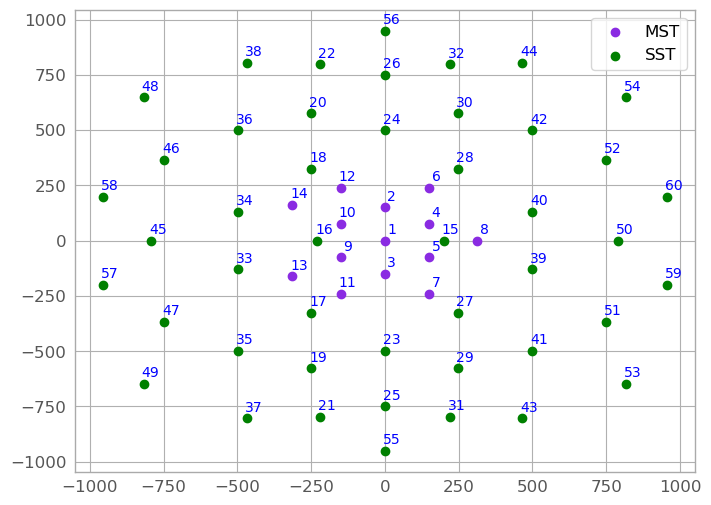

In [173]:
# Loop through all the telescopes
#for fov in array.table["fov"]:
#    print(fov)
colors = [
    'lightseagreen' if np.isclose(fov, 14.5356) else
    'blueviolet' if np.isclose(fov, 46.707) else 
    'green' if np.isclose(fov, 62.462) else
    'red'  # Default color if none of the conditions match
    for fov in array.table["fov"]
]
fov_labels = {
    'lightseagreen': 'LST',
    'blueviolet': 'MST',
    'green': 'SST'
}
for i in range(len(array.table)):
    plt.scatter(array.table['x'][i], array.table['y'][i], c=colors[i], label=fov_labels[colors[i]])

    # Annotate each point with the telescope ID
    #matplotlib.pyplot.annotate(text, xy, xytext=None, xycoords='data', textcoords=None, arrowprops=None, annotation_clip=None, **kwargs)
#Annotate the point xy with text text.
#In the simplest form, the text is placed at xy.
    plt.annotate(str(array.table["id"][i]),
                 (array.table['x'][i], array.table['y'][i]),  # Point position
                 textcoords="offset points",  # Text position relative to the point
                 xytext=(5, 5),  # Offset in pixels (to avoid overlapping the point)
                 ha='center', fontsize=10, color='blue')
handles, labels = plt.gca().get_legend_handles_labels()
#handles, labels like this is doing
    #plt.gca() gets the current Axes object, which is where your plot is
    #.get_legend_handles_labels()
        #handles: Returns a list of the graphical elements (e.g., lines, scatter plot points) that would appear in the legend.
        # labels: Returns the text labels associated with each graphical element in handles

by_label = dict(zip(labels, handles))  # Remove duplicate labels, the dictionary by the structure takes out the double 
plt.legend(by_label.values(), by_label.keys())
#by_label.values This is pulling out the unique graphical elements
# by_label.keys  This is retrieving the unique text 
plt.savefig("./different_telescopes.png", dpi=300, bbox_inches="tight")
plt.show() 

In [174]:
def multiplicity_plot(array, subarray_mult=None, fig=None, alt=None, az=None):
    if array.table.units == 'rad':
        array.__convert_units__(toDeg=True)

    coord = array.get_pointing_coord(icrs=False)
    nside = 512
    map_multiplicity = np.zeros(hp.nside2npix(nside), dtype=np.float64)

    # Initialize Healpix coordinates
    counter = np.arange(0, hp.nside2npix(nside))
    ra, dec = hp.pix2ang(nside, counter, True, lonlat=True)
    coordinate = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)

    # If subarray_mult is not provided, set all multiplicities to 1
    if subarray_mult is None:
        subarray_mult = np.ones(len(array.telescopes))

    # Iterate over telescopes
    for i, tel in tqdm.tqdm(enumerate(array.telescopes)):
        pointing = SkyCoord(ra=coord.az[i].degree, dec=coord.alt[i].degree, unit='deg')
        r_fov = np.arctan((tel.camera_radius / tel.focal).to(u.dimensionless_unscaled)).to(u.deg)
        mask = coordinate.separation(pointing) < r_fov
        map_multiplicity[mask] += subarray_mult[i]
  
    # Plotting
    R = np.sqrt(array.hFoV(m_cut=1)[0]/np.pi) + 5
    hp.cartview(map_multiplicity,
                rot=[array.pointing["az"].value, array.pointing["alt"].value],
                lonra=[-R, R], latra=[-R, R],
                nest=True, cmap='viridis',
                title=f"{array.frame.site} div={array.div}")
    plt.annotate('Azimuth (degrees)', xy=(0.5, -0.05), xycoords='axes fraction', ha='center', va='center')
    plt.annotate('Altitude (degrees)', xy=(-0.05, 0.5), xycoords='axes fraction', ha='center', va='center', rotation='vertical')
    hp.graticule(dpar=5, dmer=5, coord='G', color='gray', lw=0.5)


    # ---- ADD A RING HERE ----
    az_center = az * u.deg
    alt_center= alt * u.deg
    center = SkyCoord(az=az_center, alt=alt_center, frame='altaz')
    angles = Angle(np.linspace(0, 2*np.pi, 200), unit=u.rad)  # Position angles around the center
    ring_radius = 3.25 *u.deg
    ring = center.directional_offset_by(position_angle=angles, separation=ring_radius)

    lon = ring.az.deg
    lat = ring.alt.deg
   
   

    #lon = az_ring.value
    #lat = alt_ring.value
   
    hp.projplot(lon, lat, 'r-', lonlat=True, linewidth=1.5)
    # --------------------------

    plt.show()

In [175]:
array.divergent_pointing(0, az=0,alt=50)
coord = array.get_pointing_coord(icrs=False)
coord.az[13]
coord.alt[13]

<Latitude 50. deg>

In [176]:
array.get_pointing_coord(icrs=False)

<SkyCoord (AltAz: obstime=2025-07-11T14:43:16.833, location=(1946635.7979987, -5467633.94561753, -2642498.5212285) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    [(0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.),
     (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.),
     (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.),
     (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.),
     (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.),
     (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.),
     (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.),
     (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.),
     (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.),
     (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.), (0., 50.)]>

60it [00:08,  6.82it/s]
60it [00:08,  6.73it/s]


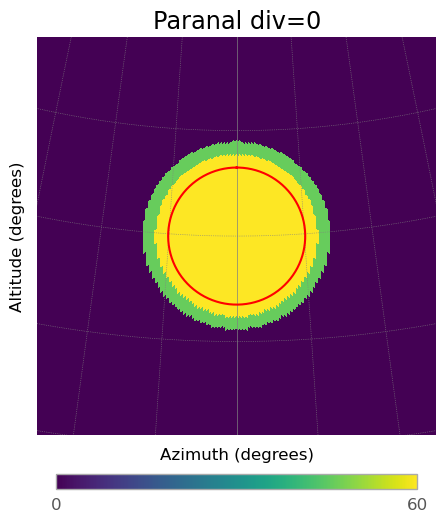

In [177]:

multiplicity_plot(array, alt=50, az=0)

The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


60it [00:08,  6.83it/s]
60it [00:08,  7.30it/s]


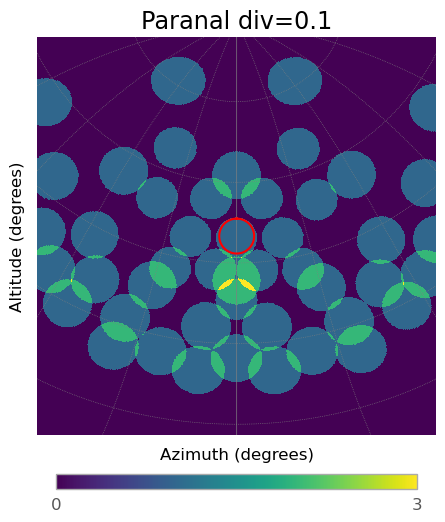

In [178]:
array.divergent_pointing(0.1, az=0,alt=50)
multiplicity_plot(array, alt=50, az=0)

The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


60it [00:08,  7.01it/s]
60it [00:08,  7.19it/s]


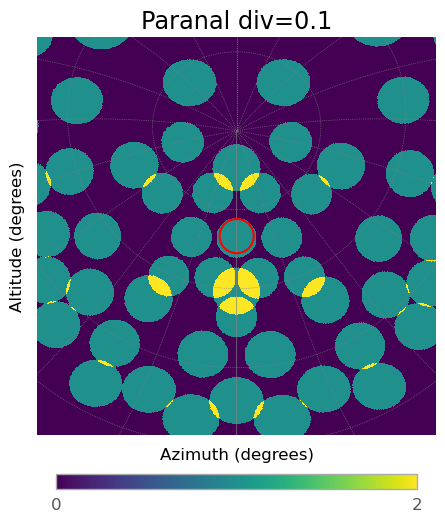

In [179]:
array.divergent_pointing(0.1, az=0,alt=70)
multiplicity_plot(array, alt=70, az=0)

The barycenter -5.783333333333333
The barycenter 0.0
The barycenter 29.183333333333334


60it [00:08,  6.77it/s]
60it [00:08,  7.29it/s]


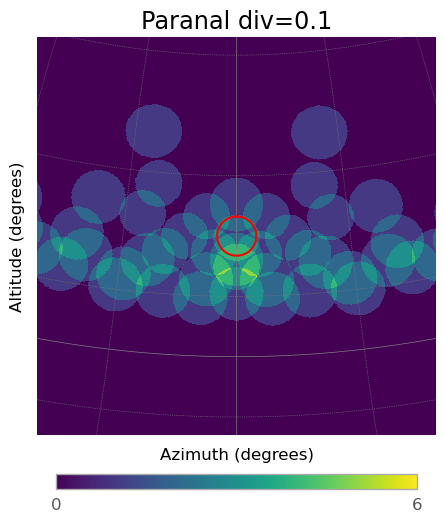

In [180]:
array.divergent_pointing(0.1, az=0,alt=20)
multiplicity_plot(array, alt=20, az=0)

In [181]:
arra

NameError: name 'arra' is not defined